# K Means Clustering

Step 1: Importing the necessary libraries
We will be importing the following libraries.

Numpy: for numerical operations (e.g., distance calculation).
Matplotlib: for plotting data and results.
Scikit learn: to create a synthetic dataset using make_blobs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

Step 2: Creating Custom Dataset
We will generate a synthetic dataset with make_blobs.

make_blobs(n_samples=500, n_features=2, centers=3): Generates 500 data points in a 2D space, grouped into 3 clusters.
plt.scatter(X[:, 0], X[:, 1]): Plots the dataset in 2D, showing all the points.
plt.show(): Displays the plot

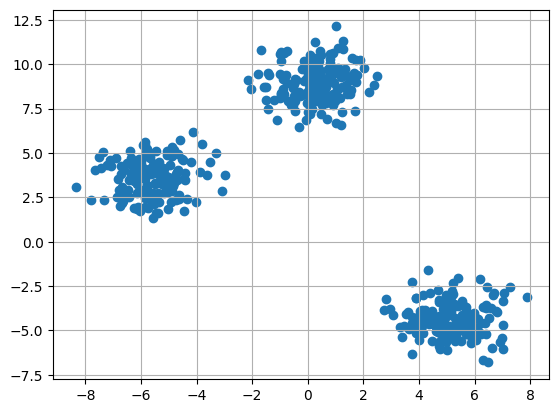

In [ ]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

Step 3: Initializing Random Centroids
We will randomly initialize the centroids for K-Means clustering

np.random.seed(23): Ensures reproducibility by fixing the random seed.
The for loop initializes k random centroids, with values between -2 and 2, for a 2D dataset.

In [ ]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }

    clusters[idx] = cluster

clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

Step 4: Plotting Random Initialized Center with Data Points
We will now plot the data points and the initial centroids.

plt.grid(): Plots a grid.
plt.scatter(center[0], center[1], marker='*', c='red'): Plots the cluster center as a red star (* marker).

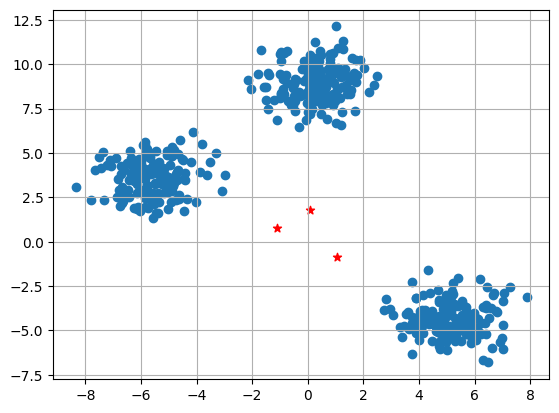

In [ ]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

Step 5: Defining Euclidean Distance
To assign data points to the nearest centroid, we define a distance function:

np.sqrt(): Computes the square root of a number or array element-wise.
np.sum(): Sums all elements in an array or along a specified axis

In [ ]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

Step 6: Creating Assign and Update Functions
Next, we define functions to assign points to the nearest centroid and update the centroids based on the average of the points assigned to each cluster.

dist.append(dis): Appends the calculated distance to the list dist.
curr_cluster = np.argmin(dist): Finds the index of the closest cluster by selecting the minimum distance.
new_center = points.mean(axis=0): Calculates the new centroid by taking the mean of the points in the cluster.

In [ ]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []

        curr_x = X[idx]

        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center

            clusters[i]['points'] = []
    return clusters

Step 7: Predicting the Cluster for the Data Points
We create a function to predict the cluster for each data point based on the final centroids.

pred.append(np.argmin(dist)): Appends the index of the closest cluster (the one with the minimum distance) to pred.

In [ ]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

Step 8: Assigning, Updating and Predicting the Cluster Centers
We assign points to clusters, update the centroids and predict the final cluster labels.

assign_clusters(X, clusters): Assigns data points to the nearest centroids.
update_clusters(X, clusters): Recalculates the centroids.
pred_cluster(X, clusters): Predicts the final clusters for all data points.

In [ ]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

Step 9: Plotting Data Points with Predicted Cluster Centers
Finally, we plot the data points, colored by their predicted clusters, along with the updated centroids.

center = clusters[i]['center']: Retrieves the center (centroid) of the current cluster.
plt.scatter(center[0], center[1], marker='^', c='red'): Plots the cluster center as a red triangle (^ marker).

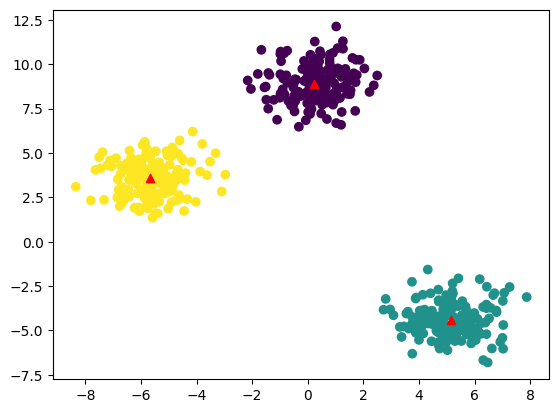

In [ ]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

# DBSCAN Clustering

Step 1: Importing Libraries
We import all the necessary library like numpy , matplotlib and scikit-learn.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import adjusted_rand_score

Step 2: Preparing Dataset
We will create a dataset of 4 clusters using make_blob. The dataset have 300 points that are grouped into 4 visible clusters.

In [ ]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)

Step 3: Applying DBSCAN Clustering
Now we apply DBSCAN clustering on our data, count it and visualize it using the matplotlib library.

eps=0.3: The radius to look for neighboring points.
min_samples: Minimum number of points required to form a dense region a cluster.
labels: Cluster numbers for each point. -1 means the point is considered noise.



['y', 'b', 'g', 'r']


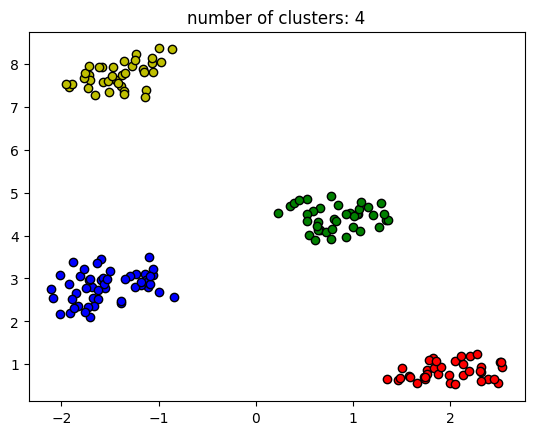

In [ ]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:

        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

As shown in above output image cluster are shown in different colours like yellow, blue, green and red.

Step 4: Evaluation Metrics For DBSCAN Algorithm In Machine Learning
We will use the Silhouette score and Adjusted rand score for evaluating clustering algorithms.

Silhouette's score is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point i is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.
Absolute Rand Score is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery.

In [ ]:
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31


Black points represent outliers. By changing the eps and the MinPts we can change the cluster configuration.

# PCA

Step 1: Importing Required Libraries
We import the necessary library like pandas, numpy, scikit learn, seaborn and matplotlib to visualize results.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Creating Sample Dataset
We make a small dataset with three features Height, Weight, Age and Gender.

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


Step 3: Standardizing the Data
Since the features have different scales Height vs Age we standardize the data. This makes all features have mean = 0 and standard deviation = 1 so that no feature dominates just because of its units.

In [3]:
X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Step 4: Applying PCA algorithm
We reduce the data from 3 features to 2 new features called principal components. These components capture most of the original information but in fewer dimensions.
We split the data into 70% training and 30% testing sets.
We train a logistic regression model on the reduced training data and predict gender labels on the test set.

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Step 5: Evaluating with Confusion Matrix
The confusion matrix compares actual vs predicted labels. This makes it easy to see where predictions were correct or wrong.

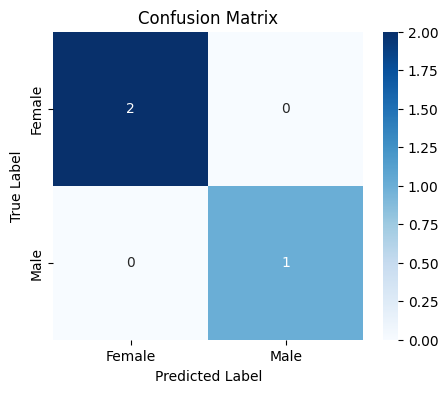

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Step 6: Visualizing PCA Result

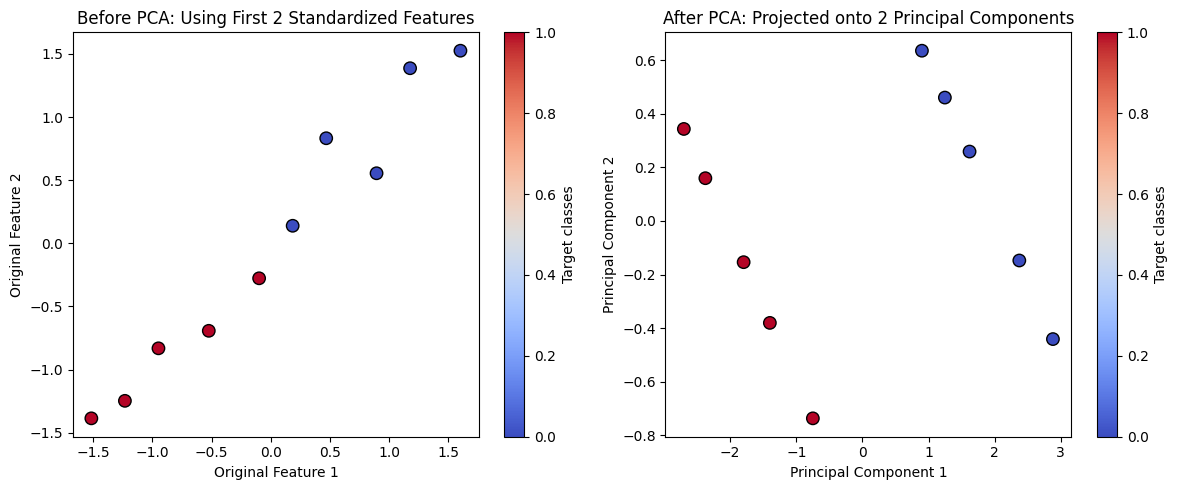

In [6]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

Left Plot Before PCA: This shows the original standardized data plotted using the first two features. There is no guarantee of clear separation between classes as these are raw input dimensions.
Right Plot After PCA: This displays the transformed data using the top 2 principal components. These new components capture the maximum variance often showing better class separation and structure making it easier to analyze or model.

# LDA

1. Importing Required Libraries
We import all necessary libraries for data processing, visualization, dimensionality reduction, and modeling

NumPy: for numerical operations and array manipulations
Pandas: for creating and managing structured datasets
Matplotlib.pyplot: for plotting and visualizations
Scikit-learn: for machine learning tools like dataset loading, preprocessing, dimensionality reduction, and classifiers

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

2. Loading the Dataset
We load the Iris dataset and convert it into a Pandas DataFrame. Features X and target labels y are separated

pd.DataFrame(columns=..., data=...) creates a DataFrame from raw data
iloc[:, 0:4] selects first four columns as features
iloc[:, 4] selects the target column

In [8]:
iris = load_iris()
dataset = pd.DataFrame(columns=iris.feature_names, data=iris.data)
dataset['target'] = iris.target

X = dataset.iloc[:, 0:4].values
y = dataset.iloc[:, 4].values

3. Data Preprocessing
We scale the features and encode the target labels, then split the dataset into training and testing sets

StandardScaler().fit_transform(X) scales features
LabelEncoder().fit_transform(y) encodes categorical labels as integers
train_test_split(X, y, test_size=0.2, random_state=42) splits data into 80% train and 20% test

In [9]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

4. Visualizing the Original Iris Dataset in 3D
We create a 3D scatter plot using the first three features to visualize the original data distribution

Axes3D enables 3D plotting
scatter(..., c=y, cmap='rainbow', alpha=0.7, edgecolors='b') colors points by class

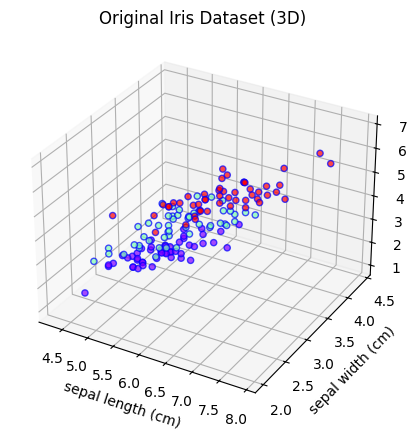

In [10]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap='rainbow', alpha=0.7, edgecolors='b')
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.set_title('Original Iris Dataset (3D)')
plt.show()

5. Random Forest Decision Boundary Without LDA
We train a Random Forest on the original features (first two features only for visualization) and plot the decision boundary

RandomForestClassifier(max_depth=2, random_state=0) initialize classifier
.fit(X_train_2D, y_train) train classifier
.predict() predict over grid for decision boundary
contourf() fills decision regions with colors

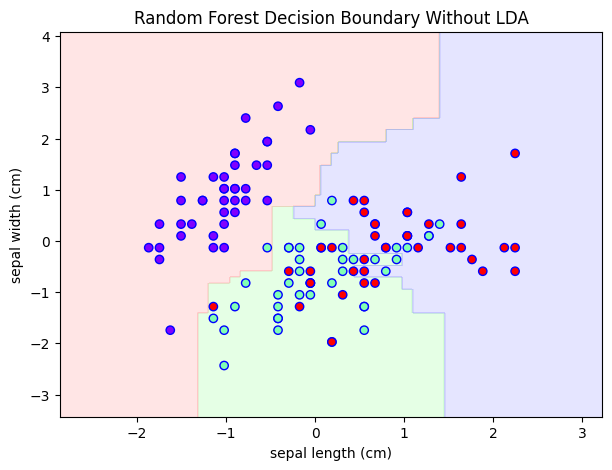

In [11]:
X_train_2D = X_train[:, :2]

rf_without_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_without_lda.fit(X_train_2D, y_train)

x_min, x_max = X_train_2D[:,0].min() - 1, X_train_2D[:,0].max() + 1
y_min, y_max = X_train_2D[:,1].min() - 1, X_train_2D[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = rf_without_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2D[:,0], X_train_2D[:,1], c=y_train, cmap='rainbow', edgecolors='b')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Random Forest Decision Boundary Without LDA')
plt.show()

7. Random Forest Decision Boundary With LDA
We train a Random Forest on LDA-transformed features and plot its decision boundary

RandomForestClassifier(max_depth=2, random_state=0) initialize classifier
.fit(X_train_lda, y_train) train classifier
.predict() predict over grid for decision boundary
contourf() fills decision regions with colors





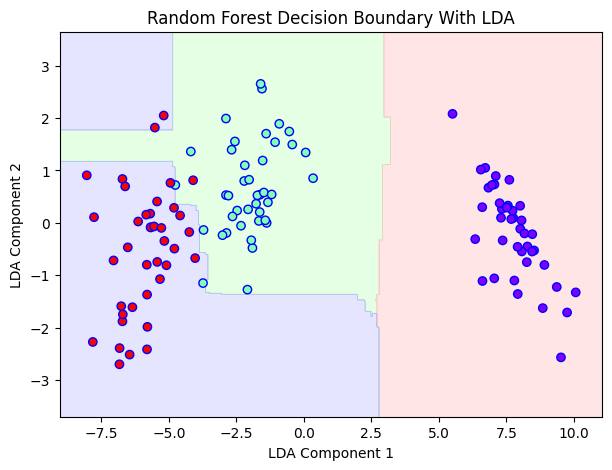

In [13]:
# Apply LDA to the training data
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)

rf_with_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_with_lda.fit(X_train_lda, y_train)

x_min, x_max = X_train_lda[:,0].min() - 1, X_train_lda[:,0].max() + 1
y_min, y_max = X_train_lda[:,1].min() - 1, X_train_lda[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = rf_with_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train, cmap='rainbow', edgecolors='b')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('Random Forest Decision Boundary With LDA')
plt.show()